# Imports

In [1]:
import xarray as xr
import numpy as np
import xeofs as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import colormaps as cmaps
from scipy.stats import t

In [2]:
ds = xr.open_dataset('/glade/work/acruz/CESM21SSTs.nc')

In [3]:
ds

<xarray.Dataset> Size: 28GB
Dimensions:  (member: 100, time: 1260, lat: 192, lon: 288)
Coordinates:
  * time     (time) object 10kB 1910-02-01 00:00:00 ... 2015-01-01 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Dimensions without coordinates: member
Data variables:
    SST      (member, time, lat, lon) float32 28GB ...

# Data select

In [4]:
ds = ds.sel(time=slice('1914-01-01', '2014-12-01'))
# Easier and faster to shift lons to -180, 180
ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
ds = ds.sortby(ds.lon)

# roll data and then assign coords, to avoid using where
ATL_ds = ds.sel(lat=slice(-10, 10), lon=slice(-60, 20))

ds = ds.assign_coords({'member': ds['member']})
ATL_ds = ATL_ds.assign_coords({'member': ATL_ds['member']})
ATL_ds

<xarray.Dataset> Size: 693MB
Dimensions:  (member: 100, time: 1212, lat: 22, lon: 65)
Coordinates:
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
Data variables:
    SST      (member, time, lat, lon) float32 693MB ...

# Anomalies

In [5]:
clim = ATL_ds.groupby('time.month').mean(dim='time')

In [6]:
anom = ATL_ds.groupby('time.month') - clim

In [7]:
anom

<xarray.Dataset> Size: 693MB
Dimensions:  (lat: 22, time: 1212, lon: 65, member: 100)
Coordinates:
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    SST      (member, time, lat, lon) float32 693MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

# Detrend
Remove later if we decide on it

In [8]:
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit


anom_dtrend = detrend_dim(anom['SST'], dim='time')
anom_dtrend

<xarray.DataArray (member: 100, time: 1212, lat: 22, lon: 65)> Size: 1GB
array([[[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [ 3.85588603e-01,  4.25269891e-01,  4.51391670e-01, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 3.71891795e-01,  3.55769825e-01,  3.77568024e-01, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 2.91347868e-01,  2.70633554e-01,  2.84907061e-01, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
...
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 1.31667195e-01,  1.25536966e-01,  1.80001564e-01, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 1.55414010e-01,  1.14979257e-01,  1.31801860e-01, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [ 3.44200818e-01,  3.54980114e-01,  3.24273129e-01, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 3.71962091e-01,  3.39405321e-01,  4.03169298e-01, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 4.06415319e-01,  3.66711591e-01,  4.37176570e-01, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]]],
      shape=(100, 1212, 22, 65))
Coordinates:
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:         K
    cell_methods:  time: mean
    bounds:        time_bnds

# EOF

In [9]:
%%time
'''
Members are not kept separate from decomposoition and its loosing the dimension after the fit

model.scores() not returning list of DataArray in same way as model.components
from source code the type annotation is dataarray instead of DataObject

as alternative I will simply loop through members and call a  new fit everytime
'''
anom_members = [anom_dtrend.sel(member=m) for m in anom_dtrend['member']]

EOF_members = []
for m in anom_members:
    model = xe.single.EOF(n_modes=3, use_coslat=True)
    model.fit(m, dim='time')
    components = model.components()
    PCs = model.scores(normalized=False)
    xplained_var = model.explained_variance_ratio()
    member_result = xr.Dataset({'components' : components, 'PCs' : PCs, 'ex_var' : xplained_var})
    EOF_members.append(member_result)

EOF_members = xr.concat(EOF_members, dim='member')
EOF_members

CPU times: user 7.87 s, sys: 8.18 ms, total: 7.88 s
Wall time: 8.31 s


<xarray.Dataset> Size: 6MB
Dimensions:     (member: 100, mode: 3, lat: 22, lon: 65, time: 1212)
Coordinates:
  * member      (member) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
  * mode        (mode) int64 24B 1 2 3
  * lat         (lat) float64 176B -9.895 -8.953 -8.01 ... 8.01 8.953 9.895
  * lon         (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
  * time        (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
    month       (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12
Data variables:
    components  (member, mode, lat, lon) float64 3MB 9.075e-24 ... -0.0
    PCs         (member, mode, time) float64 3MB 4.35 -3.88 ... -2.99 -5.828
    ex_var      (member, mode) float64 2kB 0.6138 0.136 ... 0.1503 0.06207

# Scaling and normalizing

In [10]:
pc_std = EOF_members['PCs'].std(dim='time')
pc_mean = EOF_members['PCs'].mean(dim='time')

In [11]:
normalized_PCs = (EOF_members['PCs'] - pc_mean) / pc_std
scaled_EOF = EOF_members['components'] * pc_std

In [12]:
normalized_PCs

<xarray.DataArray 'PCs' (member: 100, mode: 3, time: 1212)> Size: 3MB
array([[[ 0.4266549 , -0.38054668, -0.10282705, ...,  1.2825429 ,
          1.48281207,  1.11453022],
        [ 1.52856919,  0.78741354,  0.80640534, ...,  0.67640642,
          0.63809155,  0.92768885],
        [ 0.01064569, -0.32739202, -0.28355293, ..., -0.36303037,
         -0.25791581,  0.2217144 ]],

       [[ 1.54283021,  1.0875983 ,  0.44387688, ...,  2.48153658,
          2.17423219,  2.29851746],
        [ 0.25299658, -0.65199796, -2.13889365, ...,  0.53023843,
          0.14589536,  0.93607988],
        [-0.02610698,  0.13454486,  0.67602871, ...,  0.14881261,
          0.90118375,  0.54914441]],

       [[-1.00533325, -0.53183239, -0.37897206, ...,  1.85723161,
          2.37291995,  2.30237971],
        [ 0.21202849, -0.42885303, -0.50914513, ...,  0.71607837,
          0.21774289,  0.39688724],
        [ 0.40936717, -0.24425453,  0.84014634, ...,  0.64316082,
          0.22363212,  0.32660677]],
...
       [[ 2.11362205,  1.8413918 ,  1.23951354, ...,  0.62573555,
          0.63113402,  0.39223605],
        [ 0.37887985,  0.12943989, -1.06105831, ...,  0.64233601,
          0.29971372,  1.10557804],
        [-0.17144476, -0.67257037, -0.00266666, ..., -1.22481542,
         -1.22350491, -0.44838012]],

       [[ 0.76347605,  0.5138347 ,  0.50490614, ...,  0.39427972,
          0.11717779, -0.11857302],
        [ 0.57318712,  0.60271264,  1.00615639, ..., -0.21223005,
          0.38539988,  0.65661536],
        [-0.98978736, -0.71577951,  0.26651346, ...,  2.07536287,
          1.90860292,  1.98100079]],

       [[-0.07428581, -0.07820507, -0.46817052, ...,  1.25946537,
          2.02976763,  2.33140891],
        [ 0.40020508,  0.768094  ,  0.77388572, ...,  1.04305619,
          0.68835566,  0.15113548],
        [ 0.44541566,  0.57632628, -0.95722785, ..., -0.58520109,
         -1.02920294, -2.00565648]]], shape=(100, 3, 1212))
Coordinates:
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * mode     (mode) int64 24B 1 2 3
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2025-12-06 12:10:38
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

# CANI and EANI

In [13]:
PC1 = normalized_PCs.sel(mode=1)
PC3 = normalized_PCs.sel(mode=3)

EOF1 = scaled_EOF.sel(mode=1)
EOF3 = scaled_EOF.sel(mode=3)

EAN = (EOF1 + EOF3) / (2 ** 0.5)
CAN = (EOF1 - EOF3) / (2 ** 0.5)

EANI = (PC1 + PC3) / (2 ** 0.5)
CANI = (PC1 - PC3) / (2 ** 0.5)

# using 5 months as in literature
roll = 5
EANI_roll = EANI.rolling(time=roll, center=True).mean()
CANI_roll = CANI.rolling(time=roll, center=True).mean()

In [14]:
EANI_roll

<xarray.DataArray 'PCs' (member: 100, time: 1212)> Size: 970kB
array([[        nan,         nan, -0.12752177, ...,  0.99966597,
                nan,         nan],
       [        nan,         nan,  0.92118135, ...,  1.72903506,
                nan,         nan],
       [        nan,         nan, -0.03062788, ...,  1.86856892,
                nan,         nan],
       ...,
       [        nan,         nan,  0.53706654, ..., -0.41385591,
                nan,         nan],
       [        nan,         nan,  0.1001221 , ...,  1.12940305,
                nan,         nan],
       [        nan,         nan, -0.12909772, ...,  0.60947344,
                nan,         nan]], shape=(100, 1212))
Coordinates:
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2025-12-06 12:10:38
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

# Variances

In [15]:
# select only the summer of the index
EANI_JJA = EANI_roll.where(EANI_roll.time.dt.month.isin([6, 7, 8]), drop=True)
CANI_JJA = CANI_roll.where(CANI_roll.time.dt.month.isin([6, 7, 8]), drop=True)

EANI_JJA_mean = EANI_JJA.groupby('time.year').mean()
CANI_JJA_mean = CANI_JJA.groupby('time.year').mean()

var_roll = 21
EANI_var = EANI_JJA_mean.rolling(year=var_roll, center=True).var()
CANI_var = CANI_JJA_mean.rolling(year=var_roll, center=True).var()

CvE_r = CANI_var / EANI_var

# Plotting

## View data

In [16]:
EAN

<xarray.DataArray (member: 100, lat: 22, lon: 65)> Size: 1MB
array([[[-8.30765035e-17,  3.05105662e-16, -1.09328755e-16, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 1.97426192e-01,  1.88492487e-01,  1.85706659e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.95684075e-01,  1.89577441e-01,  1.78935506e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.89806674e-01,  1.82425610e-01,  1.71925551e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 8.41000473e-16,  1.95477698e-16, -2.98895307e-17, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
...
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.52911742e-01,  1.52156231e-01,  1.48644661e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.50515737e-01,  1.51251712e-01,  1.48256761e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[-6.38916925e-16,  3.99549653e-17, -3.56318671e-17, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 1.97182664e-01,  1.88827379e-01,  1.89724105e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.95481429e-01,  1.90900911e-01,  1.82367841e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 1.90850798e-01,  1.81612396e-01,  1.71775461e-01, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]],
      shape=(100, 22, 65))
Coordinates:
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 520B -60.0 -58.75 -57.5 -56.25 ... 17.5 18.75 20.0
Attributes: (12/15)
    model:          EOF analysis
    software:       xeofs
    version:        3.0.4
    date:           2025-12-06 12:10:38
    n_modes:        3
    center:         True
    ...             ...
    sample_name:    sample
    feature_name:   feature
    random_state:   None
    compute:        True
    solver:         auto
    solver_kwargs:  {}

## Map function

In [17]:
def ds_map(ds_to_plt, bounds=[20, -60, 10, -10], name='figure'):
    fig, ax = plt.subplots(1, 1,
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2], 5)
    lon_ticks = np.arange(bounds[1], bounds[0], 10)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.add_feature(cf.LAND)


    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0,
                              0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())
    sst_contour = ax.contourf(clon, ds_to_plt.lat, cdat,
                              levels=np.arange(-0.4, 0.5, 0.05),
                              # levels=40,
                              transform=ccrs.PlateCarree(), cmap='inferno', extend='both')
    fig.canvas.mpl_connect('resize_event', resize_colobar)
    ax.coastlines()
    plt.colorbar(sst_contour, cax=cbar_ax)
    resize_colobar(None)
    # plt.savefig(name, dpi=300)
    plt.show()


def reg_map(ds_to_plt, significance, bounds=[20, -60, 10, -10], name='figure',
           color=cmaps.posneg_1,
           lev=np.arange(-1.5, 1.5, 0.15)):

    fig, ax = plt.subplots(1, 1,
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    csig, csig_lon = cutil.add_cyclic_point(significance, significance.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2], 30)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.add_feature(cf.LAND)

# local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0,
                              0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())
    sst_contour = ax.contourf(clon, ds_to_plt.lat, cdat,
                              levels=lev,
                              # levels=40,
                              transform=ccrs.PlateCarree(), cmap=color,
                              extend='both')

    ax.contourf(csig_lon, significance.lat, csig,
                transform=ccrs.PlateCarree(),
                levels=[0, 0.05],
                colors='None',
                hatches=['....', ''],
                extend='neither',
                zorder=1)

    fig.canvas.mpl_connect('resize_event', resize_colobar)
    ax.coastlines()
    plt.colorbar(sst_contour, cax=cbar_ax)
    resize_colobar(None)
    # plt.savefig(name, dpi=300)
    plt.show()

## EOFs

### EOF ensemble means

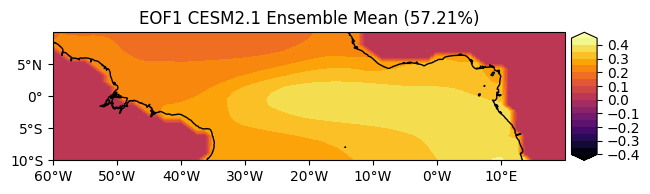

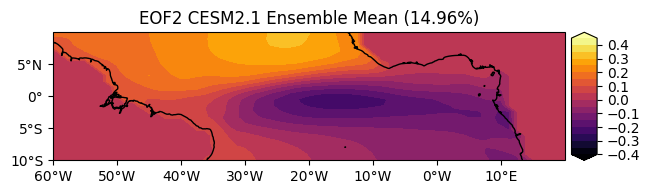

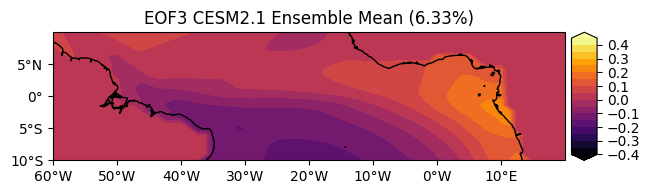

In [18]:
ens_mean_EOF1 = scaled_EOF.sel(mode=1).mean(dim='member')
ens_mean_xvar1 = EOF_members['ex_var'].sel(mode=1).mean(dim='member')
ens_mean_EOF2 = scaled_EOF.sel(mode=2).mean(dim='member')
ens_mean_xvar2 = EOF_members['ex_var'].sel(mode=2).mean(dim='member')
ens_mean_EOF3 = scaled_EOF.sel(mode=3).mean(dim='member')
ens_mean_xvar3 = EOF_members['ex_var'].sel(mode=3).mean(dim='member')


ds_map(ens_mean_EOF1, name=f'EOF1 CESM2.1 Ensemble Mean ({ens_mean_xvar1 * 100:.2f}%)')
ds_map(ens_mean_EOF2, name=f'EOF2 CESM2.1 Ensemble Mean ({ens_mean_xvar2 * 100:.2f}%)')
ds_map(ens_mean_EOF3, name=f'EOF3 CESM2.1 Ensemble Mean ({ens_mean_xvar3 * 100:.2f}%)')

### CAN and EAN ensemble mean

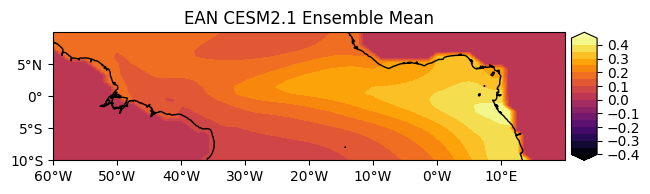

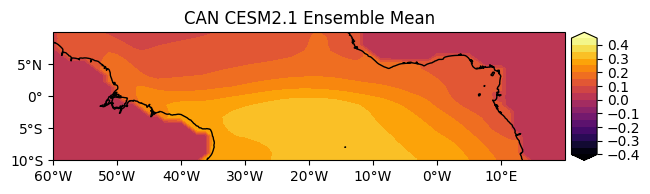

In [19]:
ens_mean_EAN = EAN.mean(dim='member')
ens_mean_CAN = CAN.mean(dim='member')

ds_map(ens_mean_EAN, name='EAN CESM2.1 Ensemble Mean')
ds_map(ens_mean_CAN, name='CAN CESM2.1 Ensemble Mean')

## Variance

### ensemble mean of eastern with ensemble mean of central through time

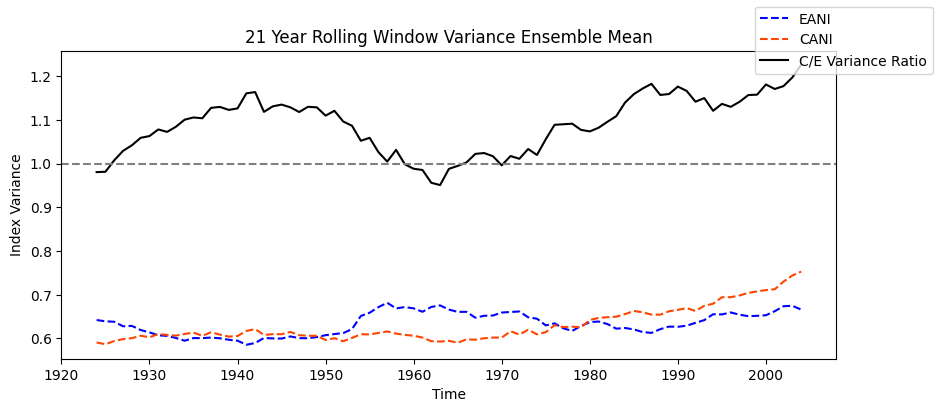

In [20]:
ens_CvE = CvE_r.mean(dim='member')
ens_EANIvar = EANI_var.mean(dim='member')
ens_CANIvar = CANI_var.mean(dim='member')

fig , ax1 = plt.subplots(figsize=(10, 4))

ens_EANIvar.plot(ax=ax1, label='EANI',  color='blue', linestyle='--')
ens_CANIvar.plot(ax=ax1, label='CANI',  color='orangered', linestyle='--')
ens_CvE.plot(ax=ax1, label='C/E Variance Ratio', color='black')
plt.title(f'21 Year Rolling Window Variance Ensemble Mean')
plt.ylabel('Index Variance')
plt.xlabel('Time')
ax1.axhline(1, color='grey', ls='--')
fig.legend()

### Eastern and central plot including all members and ensemble mean

### EANI

Text(0.5, 0, 'Year')

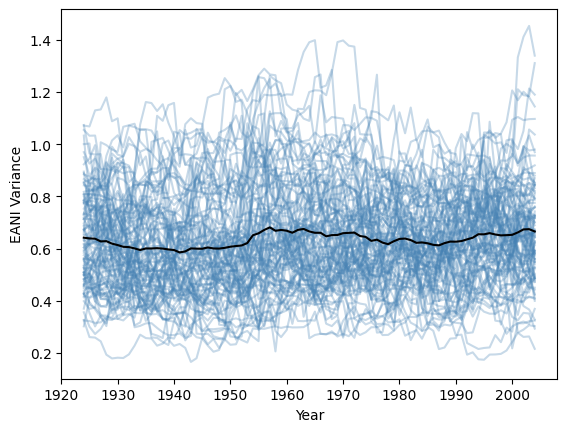

In [21]:
EANI_var.plot.line(hue='member', x='year', alpha=0.3, add_legend=False, color='steelblue')
ens_EANIvar.plot.line(color='black')
plt.ylabel('EANI Variance')
plt.xlabel('Year')

### CANI

Text(0.5, 0, 'Year')

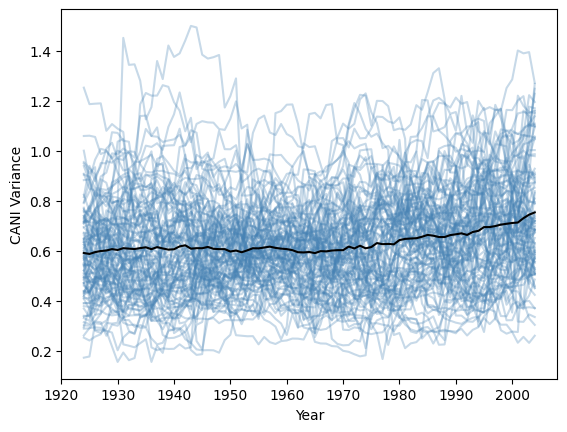

In [22]:
CANI_var.plot.line(hue='member', alpha=0.3, add_legend=False, color='steelblue')
ens_CANIvar.plot.line(color='black')
plt.ylabel('CANI Variance')
plt.xlabel('Year')

# Export

In [23]:
EANI_roll = EANI_roll.drop_attrs()
CANI_roll = CANI_roll.drop_attrs()

In [24]:
'''Data to export to regress with precipitation
CANI (time, members)
EANI (time, members)
call the values remove all weird attributes, and make a new dataset to export from there
'''
timeseries = xr.Dataset(
    data_vars={
                "EANI": EANI_roll,
                "CANI": CANI_roll
               },
    coords={"time": EANI_roll['time'].values}
)

timeseries.attrs.update({
    "title": "Atlantic Niño Index Timeseries",
    "description": f"Contains EANI, CANI calculated from CESM2.1 LE2",
    "created": "12/25/2025"
})
timeseries

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1212, member: 100)
Coordinates:
  * time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    EANI     (member, time) float64 970kB nan nan -0.1275 ... 0.6095 nan nan
    CANI     (member, time) float64 970kB nan nan 0.07744 ... 1.653 nan nan
Attributes:
    title:        Atlantic Niño Index Timeseries
    description:  Contains EANI, CANI calculated from CESM2.1 LE2
    created:      12/25/2025

In [25]:
timeseries = timeseries.drop_indexes(('member', 'time'))
timeseries

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1212, member: 100)
Coordinates:
    time     (time) object 10kB 1914-01-01 00:00:00 ... 2014-12-01 00:00:00
    member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    month    (time) int64 10kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    EANI     (member, time) float64 970kB nan nan -0.1275 ... 0.6095 nan nan
    CANI     (member, time) float64 970kB nan nan 0.07744 ... 1.653 nan nan
Attributes:
    title:        Atlantic Niño Index Timeseries
    description:  Contains EANI, CANI calculated from CESM2.1 LE2
    created:      12/25/2025

In [26]:
timeseries.to_netcdf("/glade/work/acruz/CESM/EANI_CANI_CESM.nc")